In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('CO_hex30_urban.csv')
df.head()

,id,lat,long,zone,date,CO
0,1,18.740079,98.913358,urban,2023-11-01,0.036409
1,2,18.765598,98.928916,urban,2023-11-01,0.034746
2,3,18.748585,98.928916,urban,2023-11-01,0.036228
3,4,18.731571,98.928916,urban,2023-11-01,0.037121
4,5,18.791111,98.944475,urban,2023-11-01,0.036291


version Claude AI

Null values after cleaning: 0
Data range: 0.0249 to 0.1008
Original NO2 range: 0.0249 to 0.1008
Scaled NO2 range: 0.0000 to 1.0000
Data shape: (5430, 1)
Sequences created: 5414
X shape: (5414, 16, 1), y shape: (5414, 1)


/Users/sakdahomhuan/miniforge3/envs/udfire/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0033 - mae: 0.0353 - val_loss: 0.0039 - val_mae: 0.0368
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.2521e-04 - mae: 0.0182 - val_loss: 0.0033 - val_mae: 0.0336
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.4216e-04 - mae: 0.0172 - val_loss: 0.0026 - val_mae: 0.0295
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0439e-04 - mae: 0.0171 - val_loss: 0.0031 - val_mae: 0.0370
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.2777e-04 - mae: 0.0153 - val_loss: 0.0023 - val_mae: 0.0284
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.8475e-04 - mae: 0.0144 - val_loss: 0.0028 - val_mae: 0.0343
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.1158e-04 - mae: 0.0152 - val_loss: 0.0042 - val_mae: 0.0488
Epoch 8/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.8606e-04 - mae: 0.0145 - val_loss: 0.0026 - val_mae: 0.0328
Epoch 9/100
109/109 

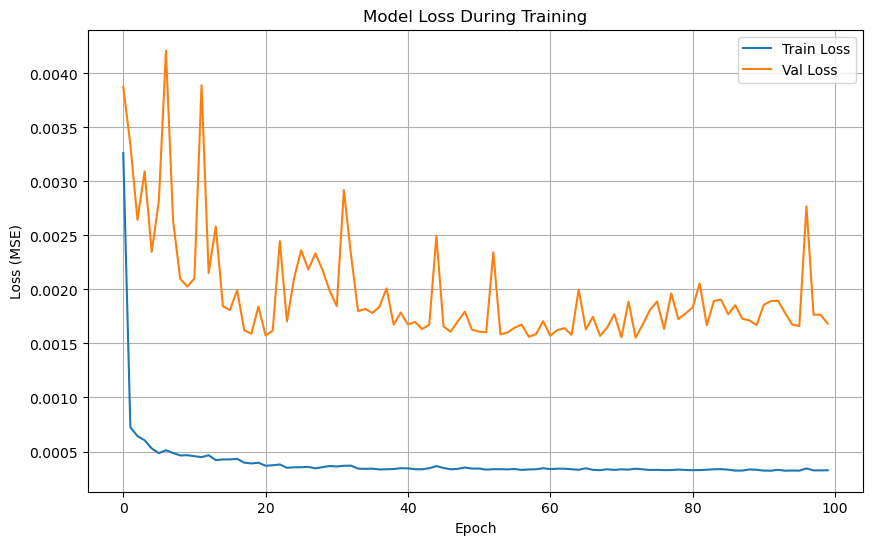

y_true shape: (1083, 1)
y_pred shape: (1083, 1)
y_true sample: [0.048699   0.0485806  0.0484622  0.04834379 0.04750238]
y_pred sample: [0.04899909 0.04888076 0.04876243 0.04864409 0.04852572]

--- Accuracy Report ---

Test Loss (MSE): 0.0012
RMSE : 0.002654
MAE  : 0.001496
R²   : 0.9655

--- Diagnostic Information ---
y_true mean: 0.063614
y_true std:  0.014286
y_pred mean: 0.063484
y_pred std:  0.013787
Correlation: 0.9828

--- 7-Day Future Prediction ---

Predictions for the next 7 days:
Day 1 (2024-04-30): 0.058168
Day 2 (2024-05-01): 0.058117
Day 3 (2024-05-02): 0.058198
Day 4 (2024-05-03): 0.058310
Day 5 (2024-05-04): 0.058479
Day 6 (2024-05-05): 0.058668
Day 7 (2024-05-06): 0.058857


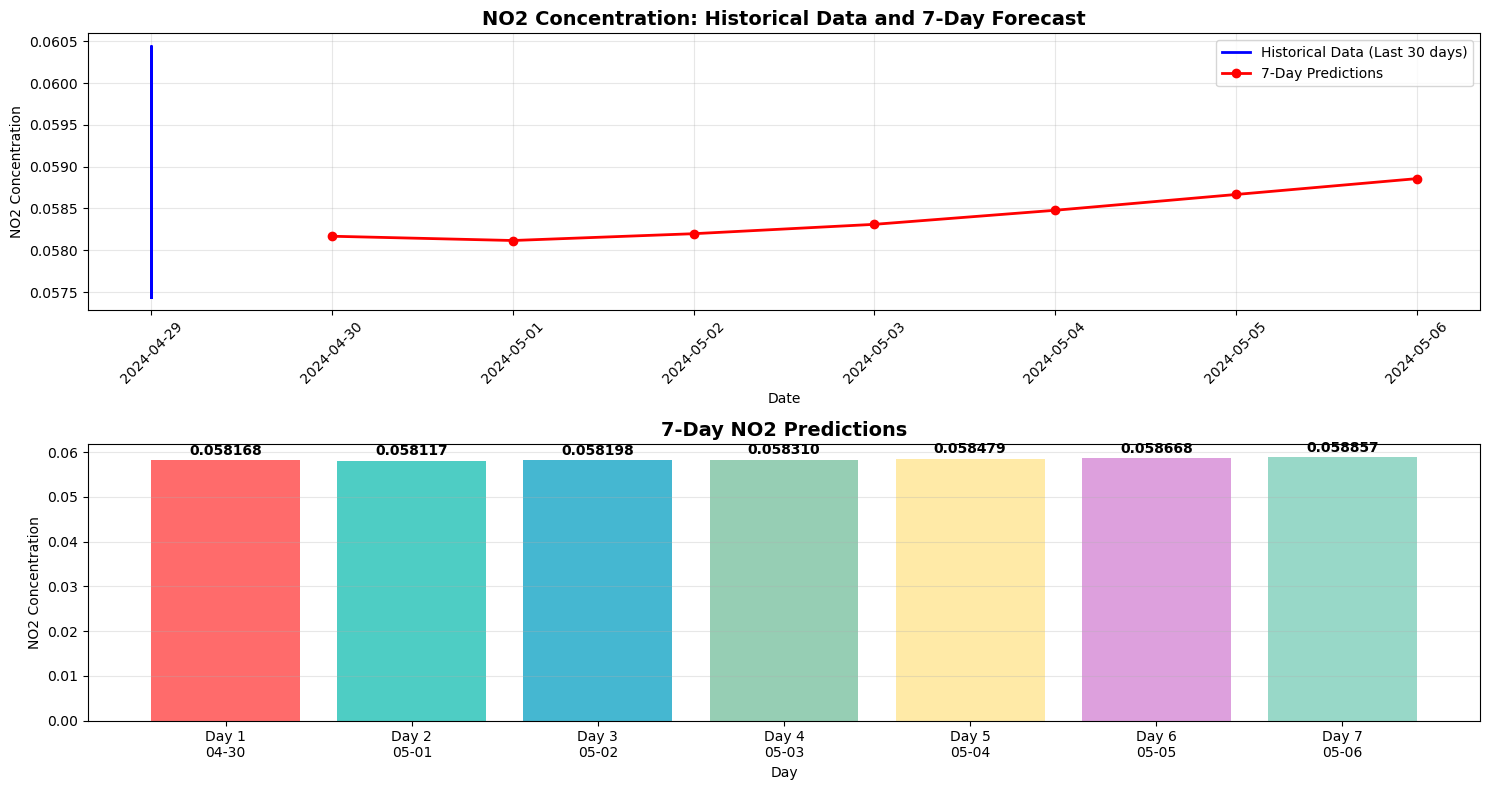

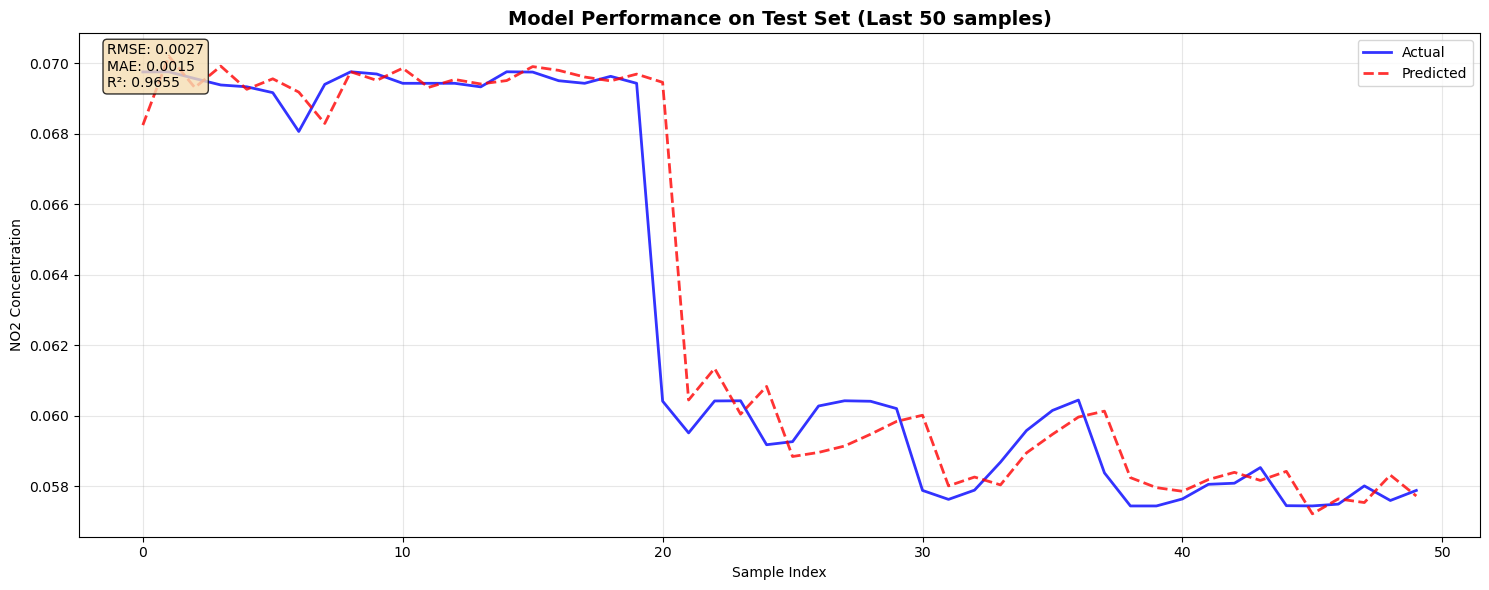


--- Summary ---
Model trained on 4331 samples
Model tested on 1083 samples
Sequence length used: 16 days
Future predictions generated: 7 days
Average predicted value for next 7 days: 0.0584
Min predicted value: 0.0581
Max predicted value: 0.0589


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

df = pd.read_csv("CO_hex30_urban.csv", parse_dates=["date"])

# แก้ไข null values ด้วย interpolation และ fill ค่าแรก/สุดท้าย
df["CO"] = df["CO"].interpolate(method='linear')  # interpolation สำหรับค่ากลาง
df["CO"] = df["CO"].bfill()  # backward fill สำหรับค่าแรก
df["CO"] = df["CO"].ffill()  # forward fill สำหรับค่าสุดท้าย

# ตรวจสอบว่ายังมี null values หรือไม่
print(f"Null values after cleaning: {df["CO"].isnull().sum()}")
print(f"Data range: {df["CO"].min():.4f} to {df["CO"].max():.4f}")

dates = pd.date_range(start="2023-11-01", end="2024-04-30", freq="D")

# Step 1: สร้างลำดับข้อมูล
def create_sequences(data, seq_len=21):
    X = np.array([data[i-seq_len:i] for i in range(seq_len, len(data))])
    y = np.array([data[i] for i in range(seq_len, len(data))])
    return X, y

# ปรับสเกล
scaler = MinMaxScaler()
no2_scaled = scaler.fit_transform(df["CO"].values.reshape(-1, 1))

# ตรวจสอบข้อมูล
print(f"Original NO2 range: {df["CO"].min():.4f} to {df["CO"].max():.4f}")
print(f"Scaled NO2 range: {no2_scaled.min():.4f} to {no2_scaled.max():.4f}")
print(f"Data shape: {no2_scaled.shape}")

sequence_length = 16 # test
X, y = create_sequences(no2_scaled, sequence_length)

print(f"Sequences created: {X.shape[0]}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train = X_train.reshape(-1, sequence_length, 1)
X_test = X_test.reshape(-1, sequence_length, 1)

model = Sequential()
model.add(LSTM(64, # เพิ่มจาก 32 -> 64
               activation="tanh", # เปลี่ยนจาก relu -> tanh
               return_sequences=False, # เพิ่มความชัดเจน
               input_shape=(sequence_length, 1)))
model.add(Dense(32, activation='relu')) # เพิ่ม hidden layer
model.add(Dense(1))

model.compile(optimizer="adam", loss="mse", metrics=['mae'])
model.summary()

history = model.fit(X_train,
                    y_train,
                    epochs=100,    # เพิ่มจาก 50 -> 100
                    batch_size=32, # เพิ่มจาก 16 -> 32
                    validation_split=0.2,
                    verbose=1, # เปลี่ยนเป็น 1 เพื่อดู progress
                    shuffle=True) # เพิ่ม shuffle

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Step 4: Evaluate Model
loss = model.evaluate(X_test, y_test, verbose=0)
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ตรวจสอบข้อมูล
print(f"y_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"y_true sample: {y_true[:5].flatten()}")
print(f"y_pred sample: {y_pred[:5].flatten()}")

# แก้ปัญหา format - แปลง loss เป็น scalar ก่อน
if isinstance(loss, list):
    loss = loss[0]  # ใช้ตัวแรกถ้าเป็น list
loss = float(loss)

rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae = float(mean_absolute_error(y_true, y_pred))
r2 = float(r2_score(y_true, y_pred))

print("\n--- Accuracy Report ---")
print(f"\nTest Loss (MSE): {loss:.4f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.6f}")
print(f"R²   : {r2:.4f}")

# เพิ่มสถิติเพื่อวินิจฉัยปัญหา
print(f"\n--- Diagnostic Information ---")
print(f"y_true mean: {float(np.mean(y_true)):.6f}")
print(f"y_true std:  {float(np.std(y_true)):.6f}")
print(f"y_pred mean: {float(np.mean(y_pred)):.6f}")
print(f"y_pred std:  {float(np.std(y_pred)):.6f}")
print(f"Correlation: {float(np.corrcoef(y_true.flatten(), y_pred.flatten())[0,1]):.4f}")

# =============================================
# เพิ่มส่วนทำนายข้อมูล 7 วันข้างหน้า
# =============================================

def predict_future(model, scaler, data, sequence_length, n_future=7):
    """
    ทำนายข้อมูลในอนาคต

    Parameters:
    - model: LSTM model ที่ train แล้ว
    - scaler: MinMaxScaler ที่ใช้ในการ normalize
    - data: ข้อมูลล่าสุดที่จะใช้เป็นพื้นฐานในการทำนาย
    - sequence_length: ความยาวของลำดับที่ใช้ในการทำนาย
    - n_future: จำนวนวันที่ต้องการทำนายข้างหน้า

    Returns:
    - predictions: array ของค่าทำนายที่ยังไม่ได้ inverse transform
    - predictions_original: array ของค่าทำนายที่ inverse transform แล้ว
    """

    # เตรียมข้อมูลล่าสุดสำหรับการทำนาย
    last_sequence = data[-sequence_length:].reshape(1, sequence_length, 1)

    predictions = []
    current_sequence = last_sequence.copy()

    # ทำนายทีละวัน
    for _ in range(n_future):
        # ทำนายค่าถัดไป
        next_pred = model.predict(current_sequence, verbose=0)
        predictions.append(next_pred[0, 0])

        # อัพเดตลำดับสำหรับการทำนายครั้งต่อไป
        # เลื่อนข้อมูลและใส่ค่าทำนายใหม่เข้าไป
        current_sequence = np.roll(current_sequence, -1, axis=1)
        current_sequence[0, -1, 0] = next_pred[0, 0]

    # แปลงกลับเป็นค่าจริง
    predictions = np.array(predictions).reshape(-1, 1)
    predictions_original = scaler.inverse_transform(predictions)

    return predictions, predictions_original.flatten()

# ทำนาย 7 วันข้างหน้า
print("\n--- 7-Day Future Prediction ---")
future_predictions_scaled, future_predictions = predict_future(
    model, scaler, no2_scaled, sequence_length, n_future=7
)

# สร้างวันที่สำหรับการทำนาย
last_date = df['date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=7, freq='D')

# แสดงผลการทำนาย
print(f"\nPredictions for the next 7 days:")
for i, (date, pred) in enumerate(zip(future_dates, future_predictions)):
    print(f"Day {i+1} ({date.strftime('%Y-%m-%d')}): {pred:.6f}")

# =============================================
# สร้างกราฟแสดงผลการทำนาย
# =============================================

# เตรียมข้อมูลสำหรับการแสดงกราฟ
# ใช้ข้อมูล 30 วันล่าสุดเพื่อให้เห็นแนวโน้ม
n_display = 30
historical_dates = df['date'].iloc[-n_display:]
historical_values = df['CO'].iloc[-n_display:]

plt.figure(figsize=(15, 8))

# กราฟข้อมูลประวัติศาสตร์
plt.subplot(2, 1, 1)
plt.plot(historical_dates, historical_values, 'b-', linewidth=2, label='Historical Data (Last 30 days)')
plt.plot(future_dates, future_predictions, 'r-', linewidth=2, marker='o', markersize=6, label='7-Day Predictions')
plt.title('NO2 Concentration: Historical Data and 7-Day Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('NO2 Concentration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# กราฟแสดงเฉพาะการทำนาย
plt.subplot(2, 1, 2)
plt.bar(range(1, 8), future_predictions, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7', '#dda0dd', '#98d8c8'])
plt.title('7-Day NO2 Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('NO2 Concentration')
plt.xticks(range(1, 8), [f'Day {i}\n{date.strftime("%m-%d")}' for i, date in enumerate(future_dates, 1)])
plt.grid(True, alpha=0.3, axis='y')

# เพิ่มค่าบนแท่งกราฟ
for i, v in enumerate(future_predictions):
    plt.text(i+1, v + max(future_predictions)*0.01, f'{v:.6f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# =============================================
# กราฟเปรียบเทียบข้อมูลจริงกับการทำนายในชุดทดสอบ
# =============================================

plt.figure(figsize=(15, 6))

# แสดงผลการทำนายในชุดทดสอบ (เฉพาะ 50 ตัวอย่างสุดท้าย)
n_show = min(50, len(y_true))
plt.plot(range(n_show), y_true[-n_show:], 'b-', linewidth=2, label='Actual', alpha=0.8)
plt.plot(range(n_show), y_pred[-n_show:], 'r--', linewidth=2, label='Predicted', alpha=0.8)

plt.title('Model Performance on Test Set (Last 50 samples)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('NO2 Concentration')
plt.legend()
plt.grid(True, alpha=0.3)

# เพิ่มสถิติบนกราฟ
plt.text(0.02, 0.98, f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}',
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n--- Summary ---")
print(f"Model trained on {len(X_train)} samples")
print(f"Model tested on {len(X_test)} samples")
print(f"Sequence length used: {sequence_length} days")
print(f"Future predictions generated: 7 days")
print(f"Average predicted value for next 7 days: {np.mean(future_predictions):.4f}")
print(f"Min predicted value: {np.min(future_predictions):.4f}")
print(f"Max predicted value: {np.max(future_predictions):.4f}")

In [9]:
from datetime import timedelta

# ============== วันที่ที่จะพยากรณ์ (อิงวันที่ล่าสุดในทั้งชุด) ==============
last_date = pd.to_datetime(df['date']).max()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                               periods=7, freq='D')

# ============== พยากรณ์แบบรายสถานี/ราย hex id ==============
seq_length = int(sequence_length)  # ใช้ค่าที่คุณกำหนดไว้แล้ว
forecasts = {}  # {f'Station_{sid}': [pred_day1,...,pred_day7]}

for sid, g in df.groupby('id'):
    # 1) ซีรีส์ NO2 ของสถานีนี้ (เรียงวันที่)
    s = g.sort_values('date')["CO"].values.reshape(-1, 1)

    # 2) สเกลด้วย scaler เดิม (อย่า fit ใหม่)
    s_scaled = scaler.transform(s)

    # 3) ถ้ายาวไม่พอ → pad ด้วยค่าล่าสุด (ที่ "สเกลแล้ว")
    if len(s_scaled) < seq_length:
        pad_val = float(s_scaled[-1, 0]) if len(s_scaled) > 0 else 0.0
        pad = np.full((seq_length - len(s_scaled), 1), pad_val, dtype=float)
        s_scaled = np.vstack([pad, s_scaled])

    # 4) ตัดลำดับล่าสุดยาว seq_length แล้วจัดรูปเป็น (1, seq_length, 1)
    current_seq = s_scaled[-seq_length:].reshape(1, seq_length, 1)

    preds_inv = []  # เก็บค่าที่ "แปลงกลับสเกลแล้ว" 7 วัน

    for _ in range(7):
        # พยากรณ์ 1 ก้าว (ได้ค่าในสเกล 0–1)
        next_scaled = float(model.predict(current_seq, verbose=0)[0, 0])

        # แปลงกลับสเกลไปเป็นค่า NO2 จริง
        next_inv = float(scaler.inverse_transform(np.array([[next_scaled]]))[0, 0])
        preds_inv.append(next_inv)

        # เลื่อนหน้าต่าง + ใส่ค่าพยากรณ์ที่ "สเกลแล้ว" กลับเข้าไปเป็นอินพุต
        current_seq = np.roll(current_seq, -1, axis=1)
        current_seq[0, -1, 0] = next_scaled

    forecasts[f'Station_{sid}'] = preds_inv

# ============== รวมเป็น DataFrame และบันทึก ==============
forecast_df = pd.DataFrame({'Date': forecast_dates})
for col, vals in forecasts.items():
    forecast_df[col] = vals

print("\n7-Day NO2 Forecast (per station):")
print(forecast_df.head())

forecast_df.to_csv("/NO2_7day_forecast_by_station.csv", index=False)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for col in list(forecast_df.columns)[1:6]:  # เลือก 5 คอลัมน์แรกหลัง Date
    plt.plot(forecast_df['Date'], forecast_df[col], marker='o', label=col)
plt.title('7-Day NO2 Forecast (Example Stations)')
plt.xlabel('Date'); plt.ylabel('NO2 Concentration')
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()




7-Day NO2 Forecast (per station):
        Date  Station_1  Station_2  Station_3  Station_4  Station_5  \
0 2024-04-30   0.058863   0.058195   0.058918   0.058630   0.057734   
1 2024-05-01   0.060698   0.060376   0.060596   0.060611   0.060195   
2 2024-05-02   0.059000   0.058805   0.058889   0.058960   0.058555   
3 2024-05-03   0.059340   0.059206   0.059265   0.059374   0.059099   
4 2024-05-04   0.060530   0.060410   0.060580   0.060587   0.060426   

   Station_6  Station_7  Station_8  Station_9  ...  Station_21  Station_22  \
0   0.058010   0.058852   0.058941   0.058754  ...    0.058276    0.056937   
1   0.060301   0.060607   0.060670   0.060727  ...    0.059969    0.058802   
2   0.058722   0.058928   0.058969   0.059153  ...    0.058764    0.057141   
3   0.059213   0.059396   0.059381   0.059628  ...    0.059440    0.057637   
4   0.060510   0.060802   0.060723   0.060897  ...    0.060790    0.058997   

   Station_23  Station_24  Station_25  Station_26  Station_27  Statio

OSError: [Errno 30] Read-only file system: '/NO2_7day_forecast_by_station.csv'

In [10]:
# =============================================
# บันทึกโมเดลและ Scaler สำหรับใช้ต่อ (CO Model)
# =============================================

import joblib
import pickle
from datetime import datetime

# สร้างชื่อไฟล์ตาม timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. บันทึก Keras Model สำหรับ CO
model_path = f"/content/drive/My Drive/USE_NO2_CO/lstm_co_modelurban_{timestamp}.h5"
model.save(model_path)
print(f"\n✅ CO Model saved to: {model_path}")

# 2. บันทึก Scaler สำหรับ CO
scaler_path = f"/content/drive/My Drive/USE_NO2_CO/courban_scaler_{timestamp}.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ CO Scaler saved to: {scaler_path}")

# 3. บันทึก Model Configuration สำหรับ CO
config = {
    'target_variable': 'CO',
    'sequence_length': sequence_length,
    'scaler_range': (scaler.data_min_[0], scaler.data_max_[0]),
    'model_architecture': {
        'lstm_units': 64,
        'dense_units': 32,
        'input_shape': (sequence_length, 1)
    },
    'training_params': {
        'epochs': 100,
        'batch_size': 32,
        'validation_split': 0.2
    },
    'performance': {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'test_loss': loss
    },
    'data_info': {
        'original_co_min': float(df['CO'].min()),
        'original_co_max': float(df['CO'].max()),
        'data_points': len(df),
        'training_samples': len(X_train),
        'test_samples': len(X_test)
    }
}

config_path = f"/content/drive/My Drive/USE_NO2_CO/co_modelurban_config_30{timestamp}.pkl"
with open(config_path, 'wb') as f:
    pickle.dump(config, f)
print(f"✅ CO Configuration saved to: {config_path}")

# =============================================
# ตัวอย่างการโหลดและใช้โมเดล CO ใหม่
# =============================================

print(f"\n{'='*50}")
print("📋 HOW TO USE THE SAVED CO MODEL:")
print(f"{'='*50}")




OSError: [Errno 30] Read-only file system: '/content'

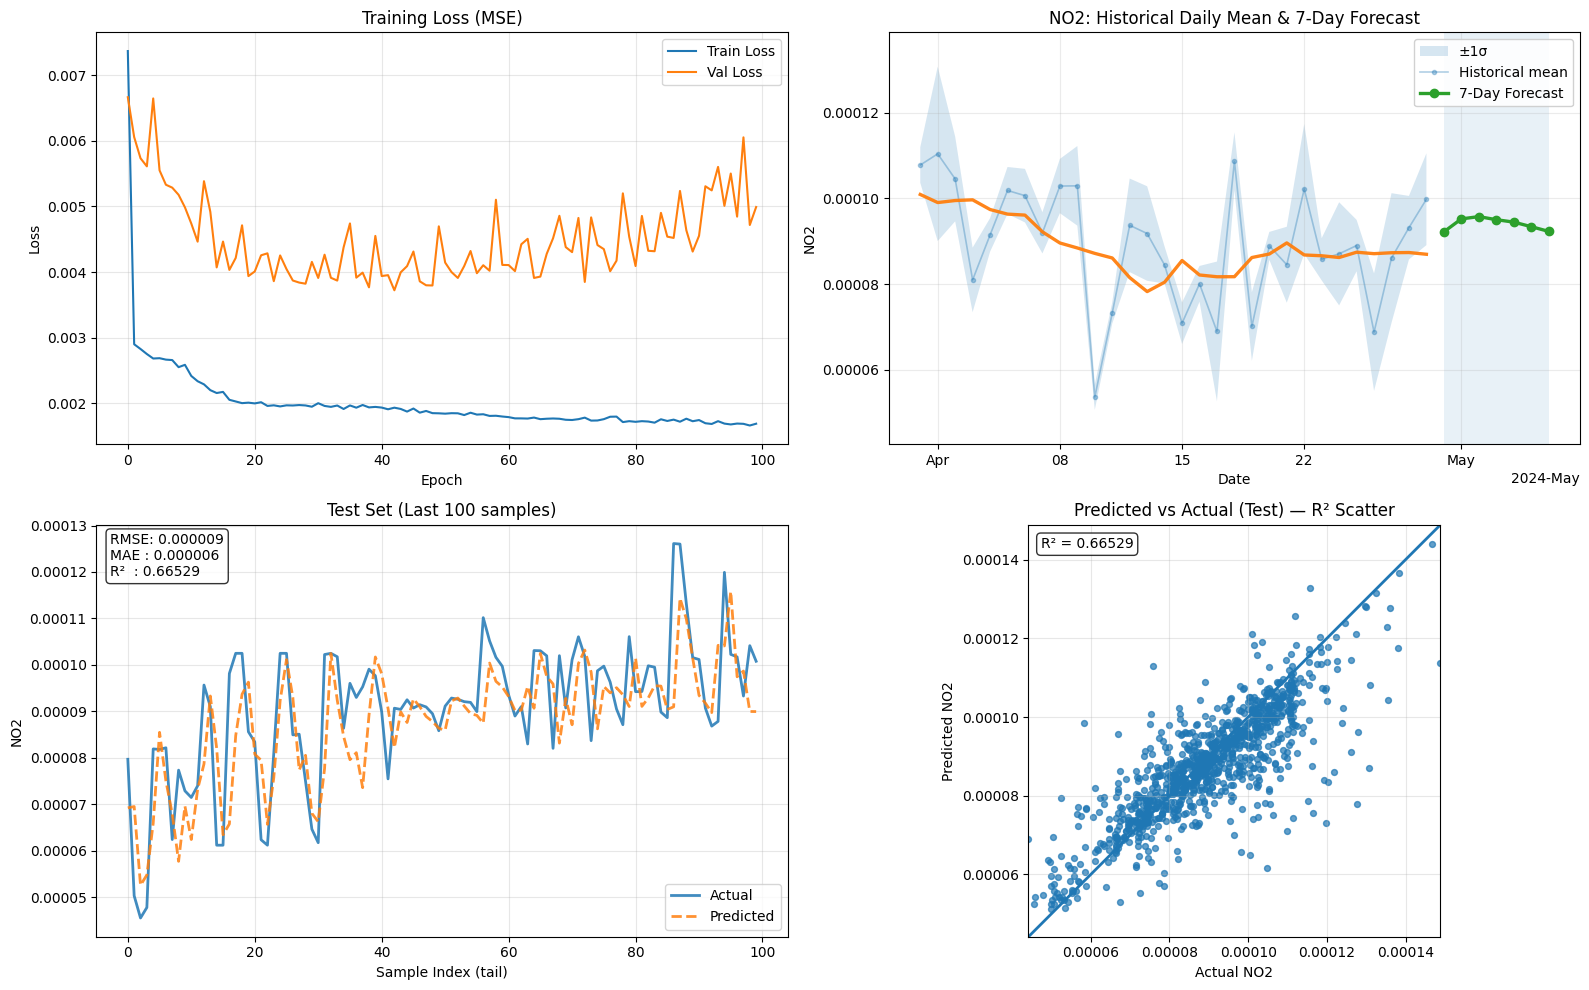

In [ ]:
# ======== FORCE SHOW 4 SUBPLOTS (2x2) ========
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# ---------- sensible defaults / fallbacks ----------
HIST_DAYS       = globals().get('HIST_DAYS', 30)        # แสดงประวัติย้อนหลัง
N_SHOW_TEST     = globals().get('N_SHOW_TEST', 100)     # จำนวนจุดท้ายสุดฝั่ง test
history         = globals().get('history', None)        # Keras History หรือ None
future_predictions = globals().get('future_predictions', [])
future_dates    = globals().get('future_dates', [])
rmse = float(globals().get('rmse', np.nan))
mae  = float(globals().get('mae',  np.nan))
r2   = float(globals().get('r2',   np.nan))

# ---------- 1) เตรียม historical: daily mean ±1σ ----------
df_plot = df[['date', "CO"]].copy()
df_plot['date'] = pd.to_datetime(df_plot['date'])
df_plot = df_plot.sort_values('date')

daily_stats = (
    df_plot.groupby('date', as_index=False)["CO"]
           .agg(mean='mean', std='std')
           .sort_values('date')
)
daily_stats['std']   = daily_stats['std'].fillna(0.0)
daily_stats['lower'] = daily_stats['mean'] - daily_stats['std']
daily_stats['upper'] = daily_stats['mean'] + daily_stats['std']

# เลือกช่วงท้ายตาม HIST_DAYS
hist_src = daily_stats.tail(HIST_DAYS if len(daily_stats) >= HIST_DAYS else len(daily_stats))

# ---------- 2) เตรียมข้อมูล test สำหรับกราฟล่างซ้าย ----------
y_true = np.asarray(globals().get('y_true', np.array([]))).flatten()
y_pred = np.asarray(globals().get('y_pred', np.array([]))).flatten()
n_pair = min(len(y_true), len(y_pred))
n_show = min(N_SHOW_TEST, n_pair)
x_idx  = np.arange(n_show)

# ---------- 3) สร้างรูป 2x2 ----------
plt.close('all')
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
(ax11, ax12), (ax21, ax22) = axes

# (1) Training/Validation Loss
train_loss = history.history.get("loss", []) if hasattr(history, 'history') else []
val_loss   = history.history.get("val_loss", []) if hasattr(history, 'history') else []
ax11.plot(train_loss, label="Train Loss")
ax11.plot(val_loss,   label="Val Loss")
ax11.set_title("Training Loss (MSE)")
ax11.set_xlabel("Epoch")
ax11.set_ylabel("Loss")
ax11.grid(True, alpha=0.3)
ax11.legend()

# (2) Historical daily mean ±1σ + 7-day Forecast — สวยงาม, ไม่มีคำว่า "smooth" ใน legend
_hist = hist_src.copy().sort_values('date').reset_index(drop=True)
if not _hist.empty:
    SMOOTH_WIN = 7 if len(_hist) >= 7 else max(1, len(_hist)//2*2+1)  # หน้าต่างเลขคี่
    _hist['mean_smooth'] = _hist['mean'].rolling(window=SMOOTH_WIN, center=True, min_periods=1).mean()

    # แถบ ±1σ โปร่ง
    ax12.fill_between(_hist['date'], _hist['lower'], _hist['upper'], alpha=0.18, label='±1σ')

    # จุด/เส้นดิบจาง ๆ
    ax12.plot(_hist['date'], _hist['mean'], linewidth=1.2, alpha=0.35,
              marker='o', markersize=3, linestyle='-', label='Historical mean')

    # เส้นเนียน (ไม่มี label → ไม่ขึ้นใน legend)
    ax12.plot(_hist['date'], _hist['mean_smooth'], linewidth=2.4, alpha=0.95)
else:
    ax12.text(0.5, 0.5, 'No historical data', ha='center', va='center', transform=ax12.transAxes)

# พยากรณ์ + ไฮไลต์ช่วง forecast
if len(future_predictions) > 0:
    fdates = pd.to_datetime(pd.Index(future_dates))
    ax12.plot(fdates, future_predictions, linewidth=2.4, marker='o', label='7-Day Forecast')
    if not _hist.empty:
        ax12.axvspan(fdates.min(), fdates.max(), alpha=0.10)

# ฟอร์แมตแกน/รายละเอียด (แกน Y แสดงค่าตรง ๆ ไม่เป็น *10^-4)
ax12.set_title('NO2: Historical Daily Mean & 7-Day Forecast')
ax12.set_xlabel('Date'); ax12.set_ylabel("CO")
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax12.xaxis.set_major_locator(locator)
ax12.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax12.ticklabel_format(style='plain', axis='y')  # <-- แสดงหน่วยเดิม
ax12.grid(True, alpha=0.25)
ax12.legend(loc='upper right', framealpha=0.9)

# ปรับ Y-limits ให้มี padding จากข้อมูล history + forecast
vals = []
if not _hist.empty:
    vals += _hist['lower'].tolist() + _hist['upper'].tolist() + _hist['mean'].tolist()
if len(future_predictions) > 0:
    vals += list(np.asarray(future_predictions, dtype=float))
if len(vals) > 0:
    lo, hi = float(np.nanmin(vals)), float(np.nanmax(vals))
    pad = (hi - lo) * 0.10 if hi > lo else (abs(hi) if hi != 0 else 1.0) * 0.10
    ax12.set_ylim(lo - pad, hi + pad)

# (3) Test set (tail) Actual vs Predicted
if n_show > 0:
    ax21.plot(x_idx, y_true[-n_show:], linewidth=2, label='Actual', alpha=0.85)
    ax21.plot(x_idx, y_pred[-n_show:], linestyle='--', linewidth=2, label='Predicted', alpha=0.85)
else:
    ax21.text(0.5, 0.5, 'No test samples', ha='center', va='center', transform=ax21.transAxes)

ax21.set_title(f'Test Set (Last {n_show} samples)')
ax21.set_xlabel('Sample Index (tail)'); ax21.set_ylabel("CO")
ax21.ticklabel_format(style='plain', axis='y')  # <-- แสดงหน่วยเดิม
ax21.grid(True, alpha=0.3); ax21.legend()
ax21.text(0.02, 0.98, f'RMSE: {rmse:.6f}\nMAE : {mae:.6f}\nR²  : {r2:.5f}',
          transform=ax21.transAxes, va='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# (4) R² Scatter: Pred vs Actual + y=x
if n_pair > 0:
    ax22.scatter(y_true, y_pred, s=18, alpha=0.7)
    lo = float(min(y_true.min(), y_pred.min()))
    hi = float(max(y_true.max(), y_pred.max()))
    if lo == hi:
        lo -= 1.0; hi += 1.0
    ax22.plot([lo, hi], [lo, hi], linewidth=2)
    ax22.set_xlim(lo, hi); ax22.set_ylim(lo, hi)
    ax22.set_aspect('equal', adjustable='box')
else:
    ax22.text(0.5, 0.5, 'No points', ha='center', va='center', transform=ax22.transAxes)

ax22.set_title('Predicted vs Actual (Test) — R² Scatter')
ax22.set_xlabel('Actual NO2'); ax22.set_ylabel('Predicted NO2')
ax22.ticklabel_format(style='plain', axis='y')  # <-- แสดงหน่วยเดิม
ax22.grid(True, alpha=0.3)
ax22.text(0.03, 0.97, f'R² = {r2:.5f}', transform=ax22.transAxes, va='top',
          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


In [ ]:
# =============================================
# บันทึกโมเดลและ Scaler สำหรับใช้ต่อ (NO2 Model)
# =============================================

import joblib
import pickle
from datetime import datetime

# สร้างชื่อไฟล์ตาม timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1. บันทึก Keras Model สำหรับ NO2
model_path = f"/content/drive/My Drive/USE_NO2_CO/lstm_no2_modelurban_{timestamp}.h5"
model.save(model_path)
print(f"\n✅ NO2 Model saved to: {model_path}")

# 2. บันทึก Scaler สำหรับ NO2
scaler_path = f"/content/drive/My Drive/USE_NO2_CO/no2urban_scaler_{timestamp}.pkl"
joblib.dump(scaler, scaler_path)
print(f"✅ NO2 Scaler saved to: {scaler_path}")

# 3. บันทึก Model Configuration สำหรับ NO2
config = {
    'target_variable': "CO",
    'sequence_length': sequence_length,
    'scaler_range': (scaler.data_min_[0], scaler.data_max_[0]),
    'model_architecture': {
        'lstm_units': 64,
        'dense_units': 32,
        'input_shape': (sequence_length, 1)
    },
    'training_params': {
        'epochs': 100,
        'batch_size': 32,
        'validation_split': 0.2
    },
    'performance': {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'test_loss': loss
    },
    'data_info': {
        'original_no2_min': float(df["CO"].min()),
        'original_no2_max': float(df["CO"].max()),
        'data_points': len(df),
        'training_samples': len(X_train),
        'test_samples': len(X_test)
    }
}

config_path = f"/content/drive/My Drive/USE_NO2_CO/no2_model_config_30urban{timestamp}.pkl"
with open(config_path, 'wb') as f:
    pickle.dump(config, f)
print(f"✅ NO2 Configuration saved to: {config_path}")

# =============================================
# ตัวอย่างการโหลดและใช้โมเดล NO2 ใหม่
# =============================================

print(f"\n{'='*50}")
print("📋 HOW TO USE THE SAVED NO2 MODEL:")
print(f"{'='*50}")



✅ NO2 Model saved to: /content/drive/My Drive/USE_NO2_CO/lstm_no2_modelurban_20250919_072826.h5
✅ NO2 Scaler saved to: /content/drive/My Drive/USE_NO2_CO/no2urban_scaler_20250919_072826.pkl
✅ NO2 Configuration saved to: /content/drive/My Drive/USE_NO2_CO/no2_model_config_30urban20250919_072826.pkl

📋 HOW TO USE THE SAVED NO2 MODEL:


In [ ]:
# ========================================
# Load saved model & components (Keras 3 safe)
# ========================================
import numpy as np
import pandas as pd
import joblib, pickle
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model
# from sklearn.preprocessing import MinMaxScaler  # not needed here

# --- paths you already have defined ---
model_path =
scaler_path = ...
config_path = ...

# 1) Load model WITHOUT compiling; then compile with explicit objects
model = load_model(model_path, compile=False)
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.MeanAbsoluteError()],
)

# 2) Load scaler + config
scaler = joblib.load(scaler_path)
with open(config_path, 'rb') as f:
    config = pickle.load(f)

sequence_length = config['sequence_length']
print("Model loaded successfully!")
print(f"Sequence length: {sequence_length}")
if 'performance' in config and 'r2' in config['performance']:
    print(f"Model performance - R²: {config['performance']['r2']:.4f}")

# ========================================
# Prediction helpers
# ========================================
def predict_new_data(new_data, model, scaler, sequence_length):
    """
    Predict next-day value from the latest sequence_length values in new_data.
    """
    if len(new_data) < sequence_length:
        raise ValueError(f"Need at least {sequence_length} data points, got {len(new_data)}")

    recent_data = np.asarray(new_data[-sequence_length:], dtype=float)
    scaled = scaler.transform(recent_data.reshape(-1, 1))
    X_new = scaled.reshape(1, sequence_length, 1)

    pred_scaled = model.predict(X_new, verbose=0)
    pred = scaler.inverse_transform(pred_scaled)
    return float(pred[0, 0])

def predict_future_days(recent_data, model, scaler, sequence_length, n_days=7):
    """
    Iteratively predict n_days into the future (uses own predictions).
    """
    preds = []
    cur = np.asarray(recent_data, dtype=float).copy()
    for _ in range(n_days):
        nxt = predict_new_data(cur, model, scaler, sequence_length)
        preds.append(float(nxt))
        cur = np.append(cur[-sequence_length+1:], nxt)
    return preds

# ========================================
# Example usage (toy data)
# ========================================
sample_data = np.array([
    25.5, 28.2, 31.1, 29.8, 26.7, 24.3, 27.9,
    30.2, 28.5, 25.8, 29.1, 31.7, 28.9, 26.4,
    25.1, 27.6, 30.3, 29.5
], dtype=float)

if len(sample_data) >= sequence_length:
    tomorrow = predict_new_data(sample_data, model, scaler, sequence_length)
    print(f"Tomorrow's NO2 prediction: {tomorrow:.4f}")

    week_predictions = predict_future_days(sample_data, model, scaler, sequence_length, n_days=7)
    print("Next 7 days predictions:")
    for i, pred in enumerate(week_predictions, 1):
        print(f"  Day {i}: {pred:.6f}")

# ========================================
# Testing with your real dataframe (define df before this!)
# ========================================
# Ensure df exists; e.g.:
# df = pd.read_csv("/content/drive/My Drive/hex_NO2_CO/NO2_urban.csv", parse_dates=["date"])
# assert "CO" in df.columns, "df must contain a "CO" column"

if 'df' in globals():
    latest_data = df["CO"].values[-sequence_length:]
    if len(latest_data) >= sequence_length:
        scaled_latest = scaler.transform(latest_data.reshape(-1, 1))
        X_test_latest = scaled_latest.reshape(1, sequence_length, 1)

        next_day_pred_scaled = model.predict(X_test_latest, verbose=0)
        next_day_pred = scaler.inverse_transform(next_day_pred_scaled).ravel()[0]

        print(f"Last {sequence_length} days average: {np.mean(latest_data):.6f}")
        print(f"Next day prediction: {next_day_pred:.6f}")
        print(f"Change from average: {next_day_pred - np.mean(latest_data):+.6f}")

print("\n✅ Model is ready to use! ")


Model loaded successfully!
Sequence length: 16
Model performance - R²: 0.6283
Tomorrow's NO2 prediction: 0.0005
Next 7 days predictions:
  Day 1: 0.000528
  Day 2: 0.000189
  Day 3: 0.000234
  Day 4: 0.000295
  Day 5: 0.000292
  Day 6: 0.000314
  Day 7: 0.000316
Last 16 days average: 0.000102
Next day prediction: 0.000087
Change from average: -0.000015

✅ Model is ready to use! 
